In [ ]:
#Назначение программы: выполнение заданий из главы 1
#Автор: Денисова Полина

In [ ]:
#Поиск пропущенных значений в каждом столбце 1.1

import pandas as pd

df = pd.read_csv('Medical_insurance.csv')

missing = df.isnull().sum()

if missing.sum() == 0:
    print("Пропущенных значений нет.")
else:
    print("Найдены пропущенные значения:")
    print(missing[missing > 0])

Пропущенных значений нет.


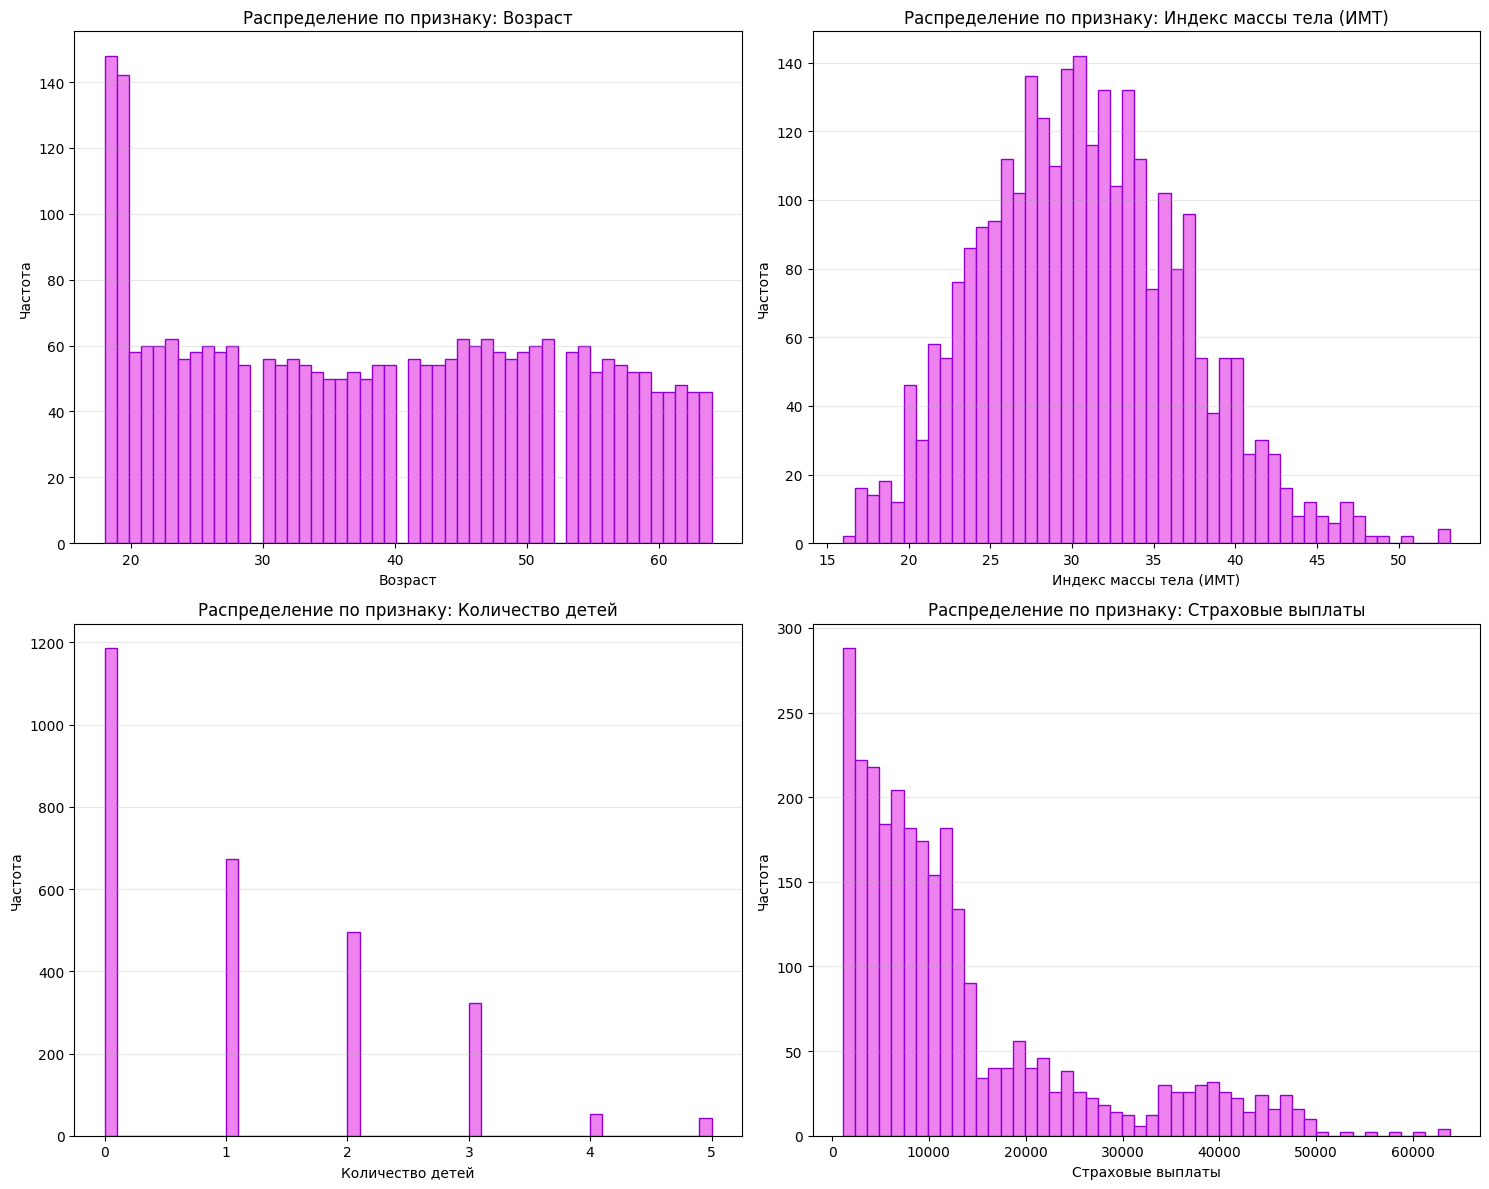

In [1]:
#Построение диаграмм 1.2.1

import matplotlib.pyplot as plt
import pandas as pd

df = pd.read_csv("Medical_insurance.csv")
numeric_cols = ["age", "bmi", "children", "charges"]
ru_names = {
    "age": "Возраст",
    "bmi": "Индекс массы тела (ИМТ)",
    "children": "Количество детей",
    "charges": "Страховые выплаты",
}

plt.figure(figsize=(15, 12))
for i, col in enumerate(numeric_cols, start=1):
    plt.subplot(2, 2, i)
    plt.hist(df[col], bins=50, edgecolor="darkviolet", alpha=1, color="violet")
    plt.title(f"Распределение по признаку: {ru_names[col]}")
    plt.xlabel(ru_names[col])
    plt.ylabel("Частота")
    plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

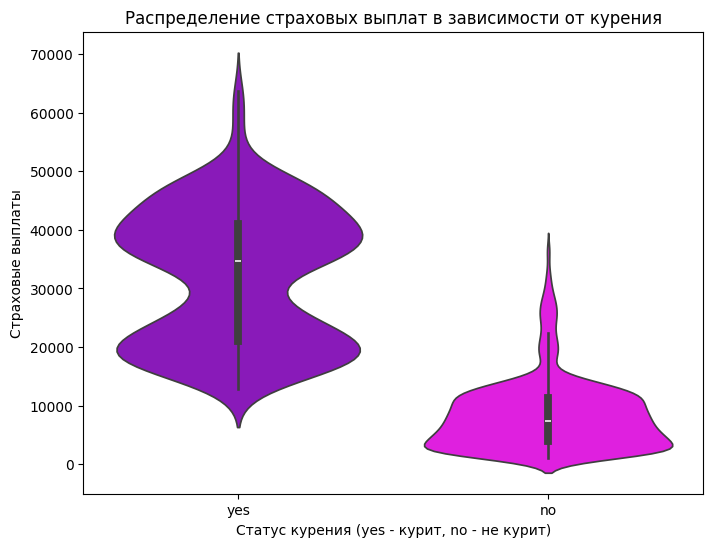

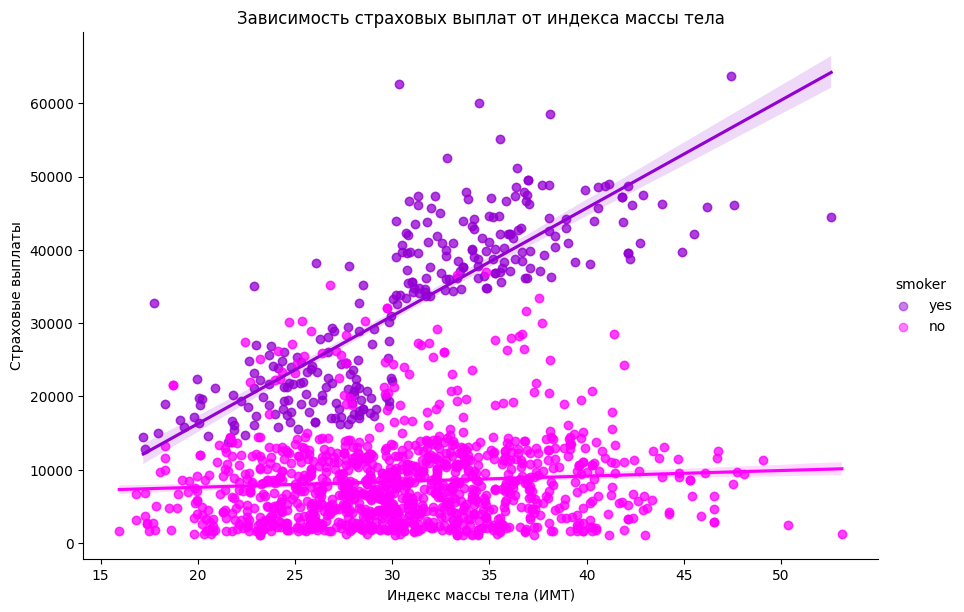

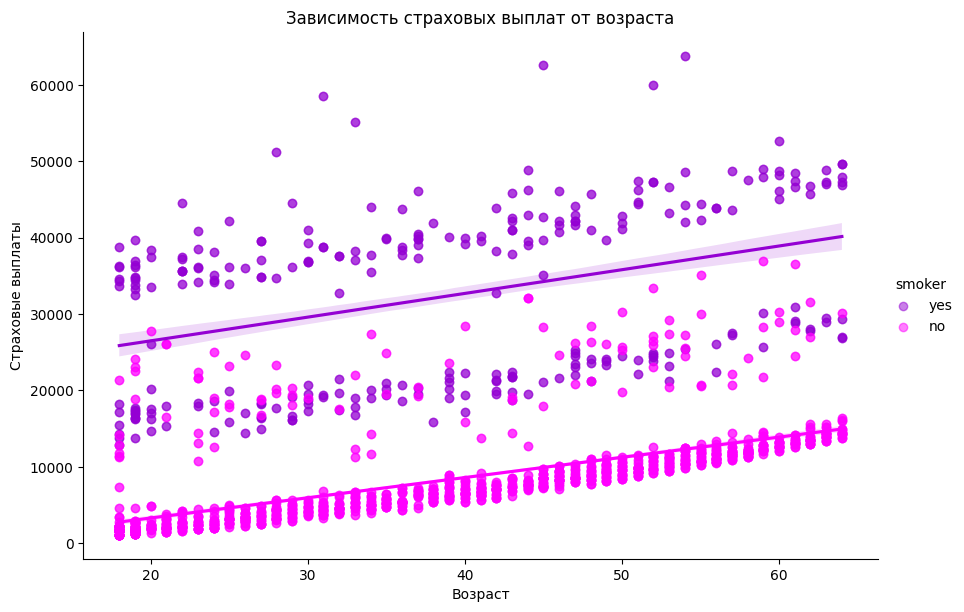

In [2]:
#Визуализация с помощью Seaborn 1.2.2

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

df = pd.read_csv("Medical_insurance.csv")

plt.figure(figsize=(8, 6))
sns.violinplot(
    data=df,
    x="smoker",
    y="charges",
    hue="smoker",
    palette={"yes": "darkviolet", "no": "fuchsia"},
    legend=False,
)
plt.title("Распределение страховых выплат в зависимости от курения")
plt.xlabel("Статус курения (yes - курит, no - не курит)")
plt.ylabel("Страховые выплаты")
plt.show()

g1 = sns.lmplot(
    data=df,
    x="bmi",
    y="charges",
    hue="smoker",
    palette={"yes": "darkviolet", "no": "fuchsia"},
    scatter_kws={"alpha": 0.5},
    height=6,
    aspect=1.5,
)
g1.ax.set_title("Зависимость страховых выплат от индекса массы тела")
g1.ax.set_xlabel("Индекс массы тела (ИМТ)")
g1.ax.set_ylabel("Страховые выплаты")
plt.show()

g2 = sns.lmplot(
    data=df,
    x="age",
    y="charges",
    hue="smoker",
    palette={"yes": "darkviolet", "no": "fuchsia"},
    scatter_kws={"alpha": 0.5},
    height=6,
    aspect=1.5,
)
g2.ax.set_title("Зависимость страховых выплат от возраста")
g2.ax.set_xlabel("Возраст")
g2.ax.set_ylabel("Страховые выплаты")
plt.show()

In [3]:
#Визуализация признаков средствами библиотеки pyplot 1.2.3
import pandas as pd
import plotly.express as px

df = pd.read_csv("Medical_insurance.csv")

figure_1 = px.scatter_3d(
    df,
    x="bmi",
    y="children",
    z="charges",
    color="smoker",
    symbol="sex",
    title="Зависимость стоимости страховки от ИМТ и количества детей",
    color_discrete_map={"yes": "fuchsia", "no": "darkviolet"},
)
figure_1.show()

figure_2 = px.box(
    df,
    x="region",
    y="charges",
    color="smoker",
    title="Распределение стоимости страховки по регионам",
    color_discrete_map={"yes": "fuchsia", "no": "darkviolet"},
)
figure_2.show()


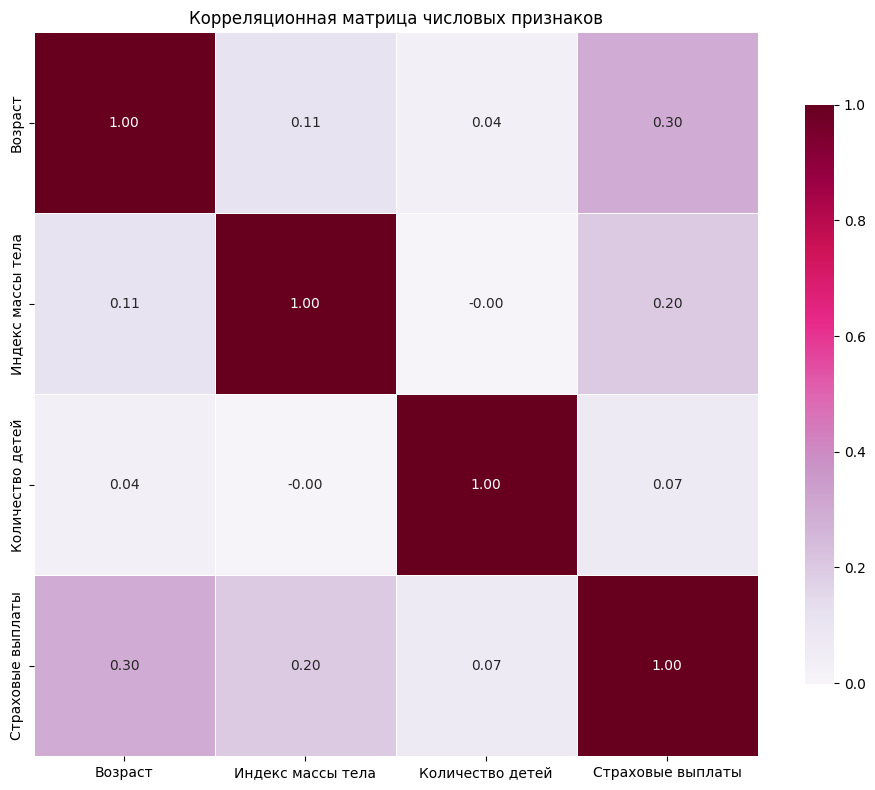

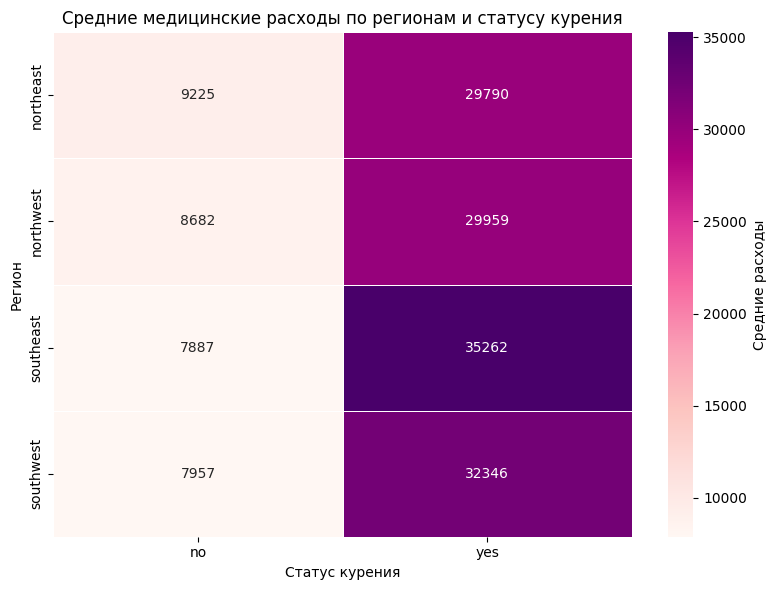

In [5]:
#Построение тепловой карты 1.2.5
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

df = pd.read_csv("Medical_insurance.csv")

numeric_cols = ["age", "bmi", "children", "charges"]
df_numeric = df[numeric_cols].copy()
df_numeric.columns = [
    "Возраст",
    "Индекс массы тела",
    "Количество детей",
    "Страховые выплаты",
]

corr_matrix = df_numeric.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="PuRd",
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8},
)
plt.title("Корреляционная матрица числовых признаков")
plt.tight_layout()
plt.show()

pivot = df.pivot_table(
    index="region", columns="smoker", values="charges", aggfunc="mean"
)
plt.figure(figsize=(8, 6))
sns.heatmap(
    pivot,
    annot=True,
    fmt=".0f",
    cmap="RdPu",
    linewidths=0.5,
    cbar_kws={"label": "Средние расходы"},
)
plt.title("Средние медицинские расходы по регионам и статусу курения")
plt.xlabel("Статус курения")
plt.ylabel("Регион")
plt.tight_layout()
plt.show()

In [6]:
#Устранение дубликатов строк 1.2.6

import pandas as pd

df = pd.read_csv("Medical_insurance.csv")
duplicates = df[df.duplicated()]

if len(duplicates) > 0:
    print(f"Найдено дубликатов строк: {len(duplicates)}")

df_no_duplicates = df.drop_duplicates()
df_no_duplicates.to_csv("Medical_insurance_clean.csv", index=False)

print(f"Было строк: {len(df)}")
print(f"Стало строк: {len(df_no_duplicates)}")
print(f"Удалено дубликатов: {len(df) - len(df_no_duplicates)}")

df_clean = pd.read_csv("Medical_insurance_clean.csv")
duplicates = df_clean[df_clean.duplicated()]

if len(duplicates) == 0:
    print("Очищенный файл не содержит дубликатов строк.")
else:
    print(f"В очищенном файле найдено дубликатов: {len(duplicates)}")
    print(duplicates.head())

Найдено дубликатов строк: 1435
Было строк: 2772
Стало строк: 1337
Удалено дубликатов: 1435
Очищенный файл не содержит дубликатов строк.


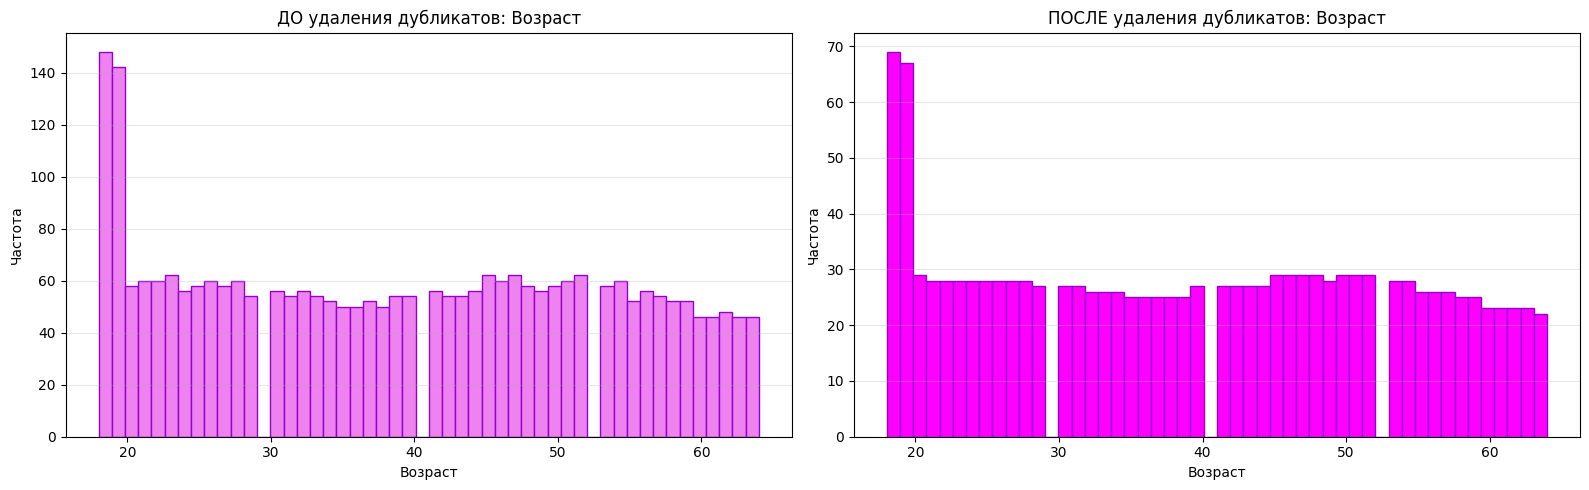

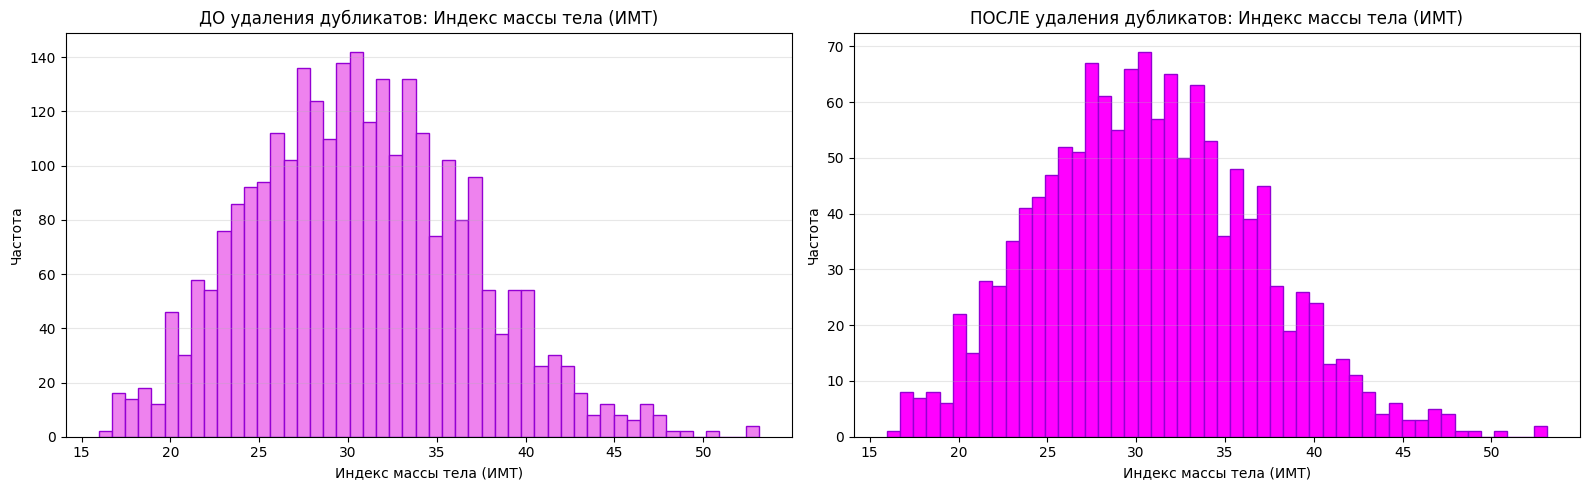

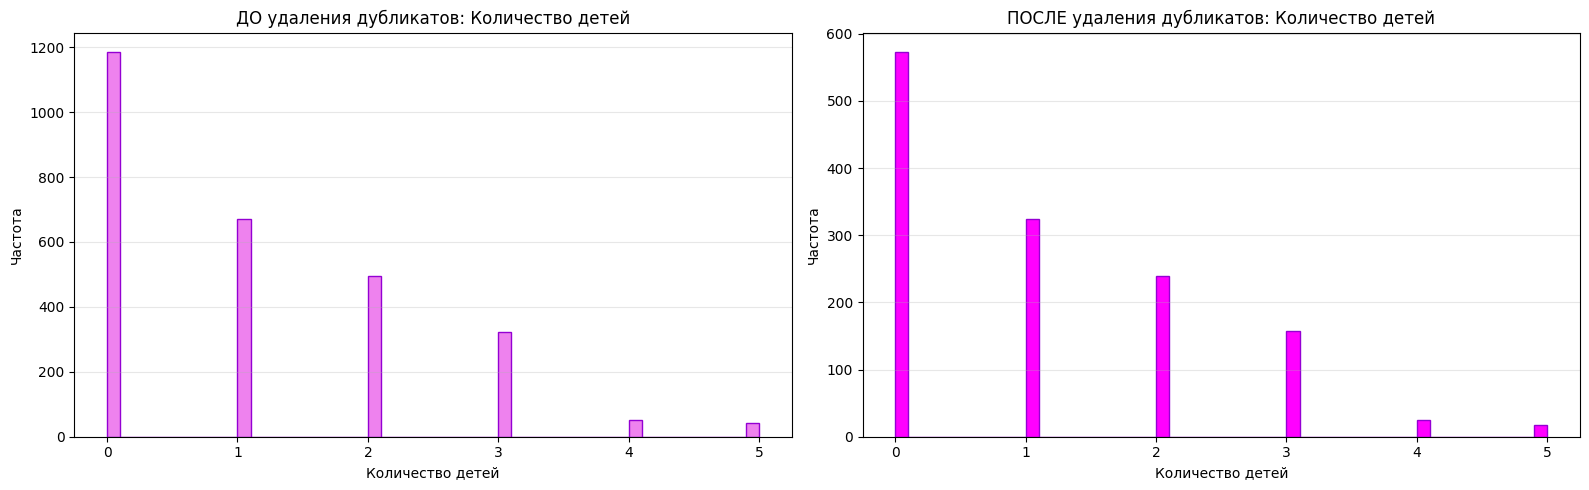

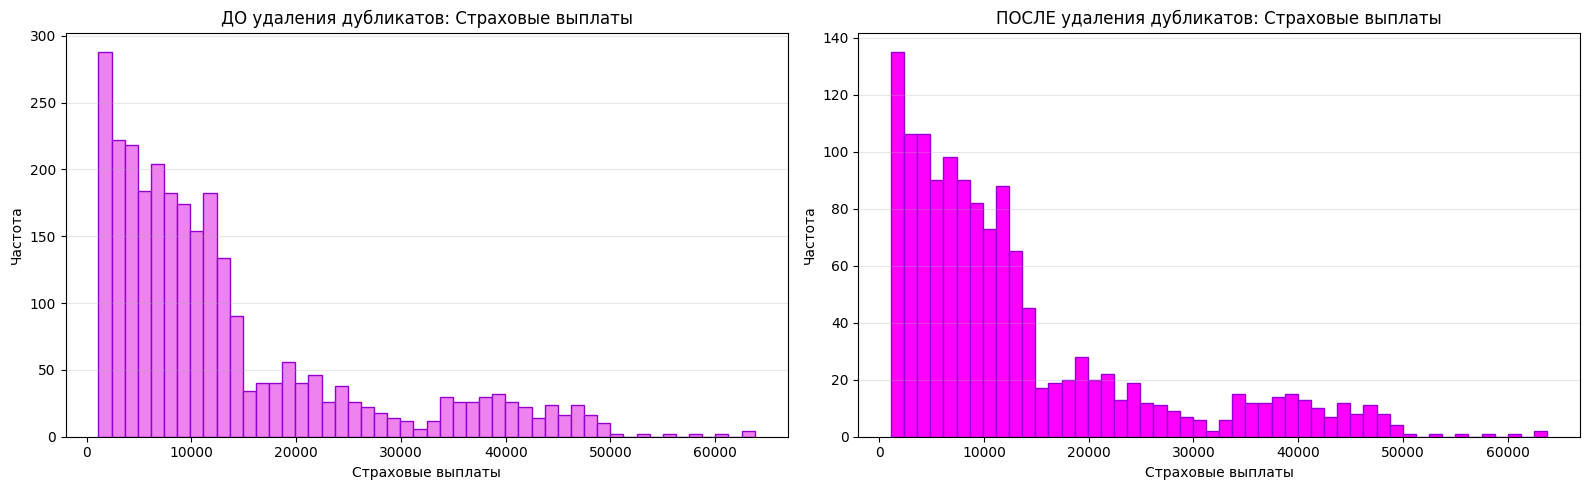

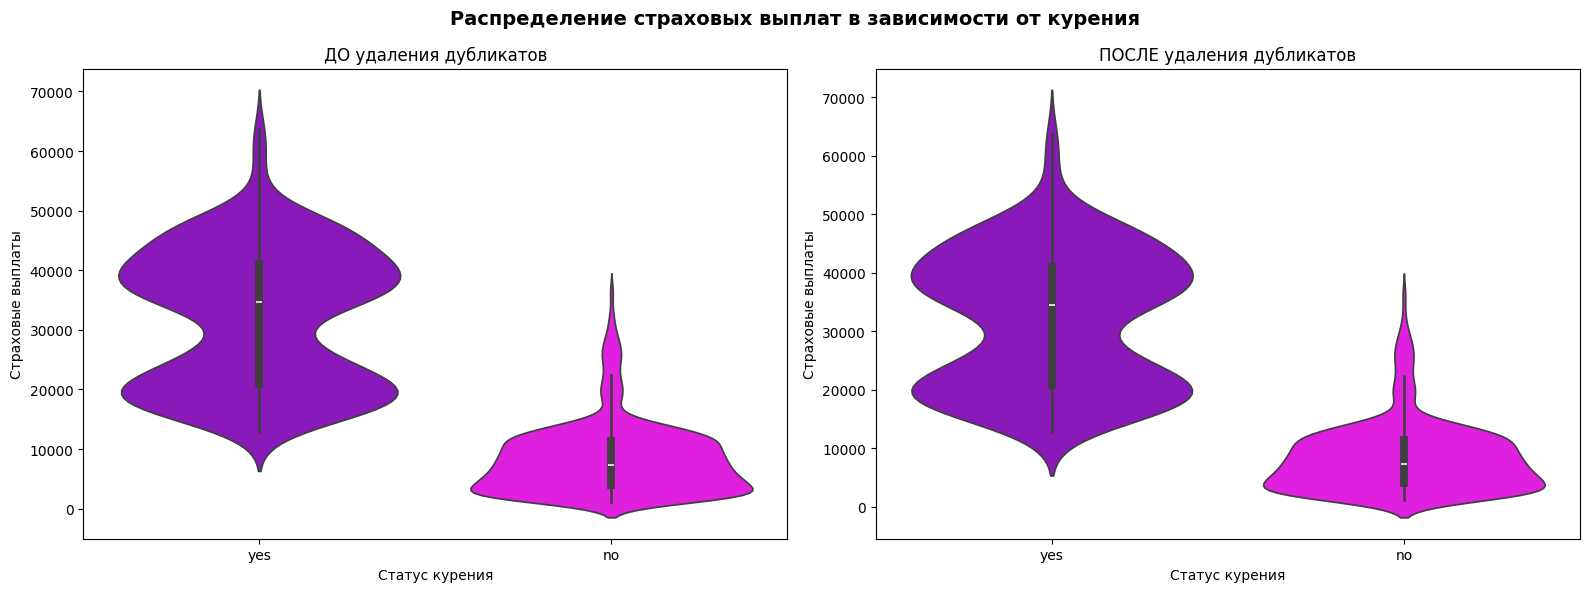

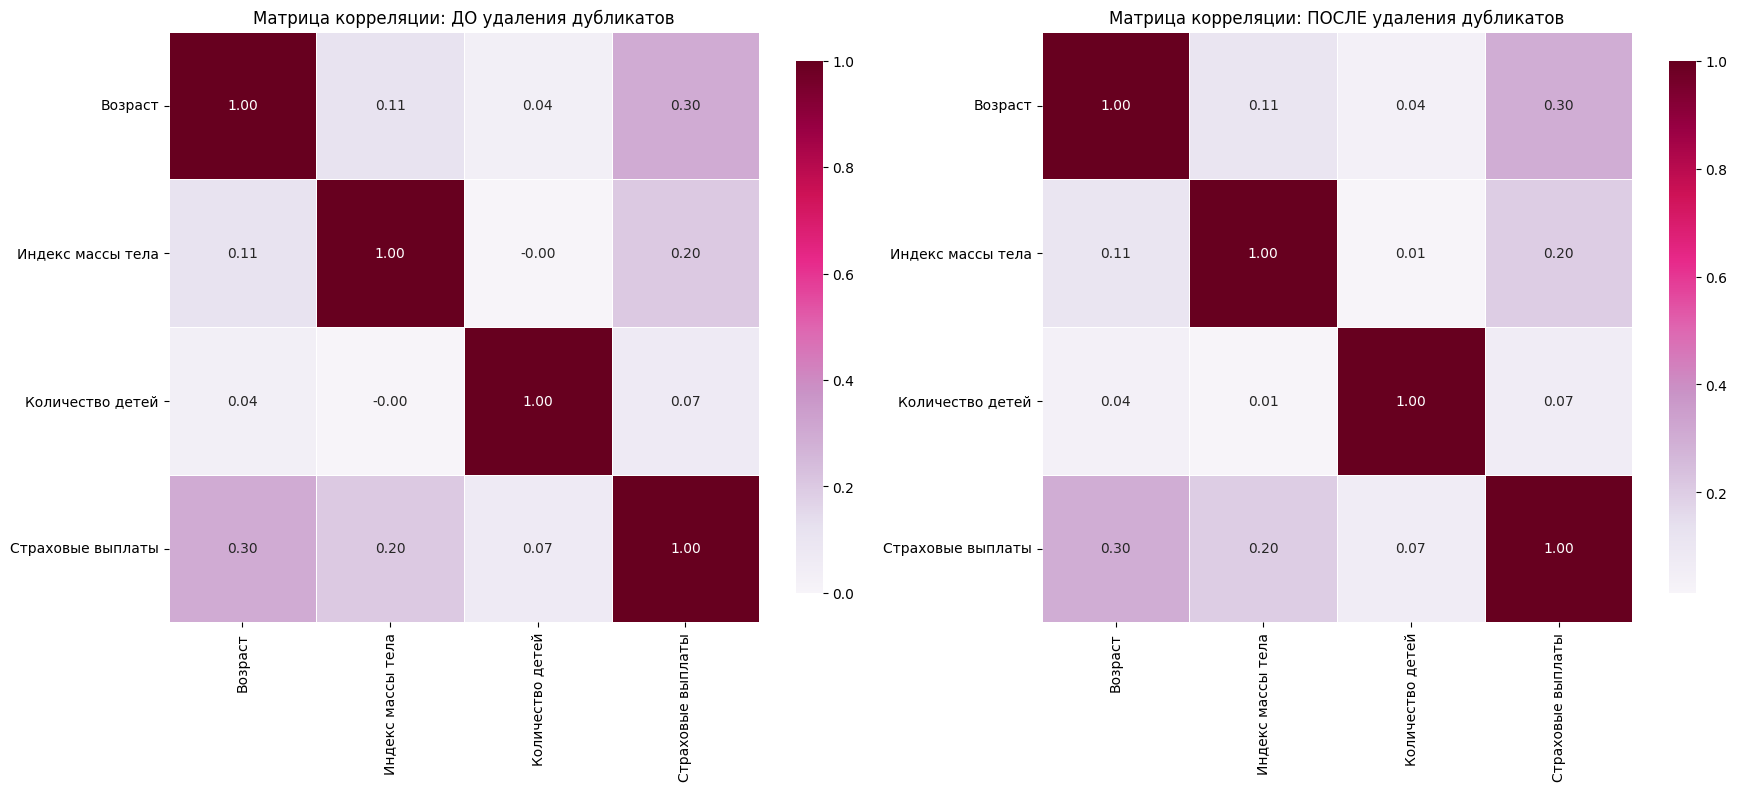

In [8]:
#Проверка корректности удаления дубликатов

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

numeric_cols = ["age", "bmi", "children", "charges"]
ru_names = {
    "age": "Возраст",
    "bmi": "Индекс массы тела (ИМТ)",
    "children": "Количество детей",
    "charges": "Страховые выплаты",
}

for col in numeric_cols:
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    axes[0].hist(
        df[col], bins=50, edgecolor="darkviolet", alpha=1, color="violet"
    )
    axes[0].set_title(f"ДО удаления дубликатов: {ru_names[col]}")
    axes[0].set_xlabel(ru_names[col])
    axes[0].set_ylabel("Частота")
    axes[0].grid(axis="y", alpha=0.3)

    axes[1].hist(
        df_clean[col], bins=50, edgecolor="darkviolet", alpha=1, color="fuchsia"
    )
    axes[1].set_title(f"ПОСЛЕ удаления дубликатов: {ru_names[col]}")
    axes[1].set_xlabel(ru_names[col])
    axes[1].set_ylabel("Частота")
    axes[1].grid(axis="y", alpha=0.3)

    plt.tight_layout()
    plt.show()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.violinplot(
    data=df,
    x="smoker",
    y="charges",
    hue="smoker",
    palette={"yes": "darkviolet", "no": "fuchsia"},
    legend=False,
    ax=axes[0],
)
axes[0].set_title("ДО удаления дубликатов")
axes[0].set_xlabel("Статус курения")
axes[0].set_ylabel("Страховые выплаты")

sns.violinplot(
    data=df_clean,
    x="smoker",
    y="charges",
    hue="smoker",
    palette={"yes": "darkviolet", "no": "fuchsia"},
    legend=False,
    ax=axes[1],
)
axes[1].set_title("ПОСЛЕ удаления дубликатов")
axes[1].set_xlabel("Статус курения")
axes[1].set_ylabel("Страховые выплаты")

plt.suptitle(
    "Распределение страховых выплат в зависимости от курения",
    fontsize=14,
    fontweight="bold",
)
plt.tight_layout()
plt.show()

df_num_before = df[numeric_cols].copy()
df_num_before.columns = [
    "Возраст",
    "Индекс массы тела",
    "Количество детей",
    "Страховые выплаты",
]

df_num_after = df_clean[numeric_cols].copy()
df_num_after.columns = [
    "Возраст",
    "Индекс массы тела",
    "Количество детей",
    "Страховые выплаты",
]

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

sns.heatmap(
    df_num_before.corr(),
    annot=True,
    fmt=".2f",
    cmap="PuRd",
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8},
    ax=axes[0],
)
axes[0].set_title("Матрица корреляции: ДО удаления дубликатов")

sns.heatmap(
    df_num_after.corr(),
    annot=True,
    fmt=".2f",
    cmap="PuRd",
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8},
    ax=axes[1],
)
axes[1].set_title("Матрица корреляции: ПОСЛЕ удаления дубликатов")

plt.tight_layout()
plt.show()


=== Возраст ===
Границы: [-9.00, 87.00]
Количество выбросов: 0

=== Индекс массы тела (ИМТ) ===
Границы: [13.67, 47.32]
Количество выбросов: 9
       bmi
116  49.06
286  48.07
401  47.52
543  47.41
846  50.38

=== Количество детей ===
Границы: [-3.00, 5.00]
Количество выбросов: 0

=== Страховые выплаты ===
Границы: [-13120.72, 34524.78]
Количество выбросов: 139
       charges
14  39611.7577
19  36837.4670
23  37701.8768
29  38711.0000
30  35585.5760


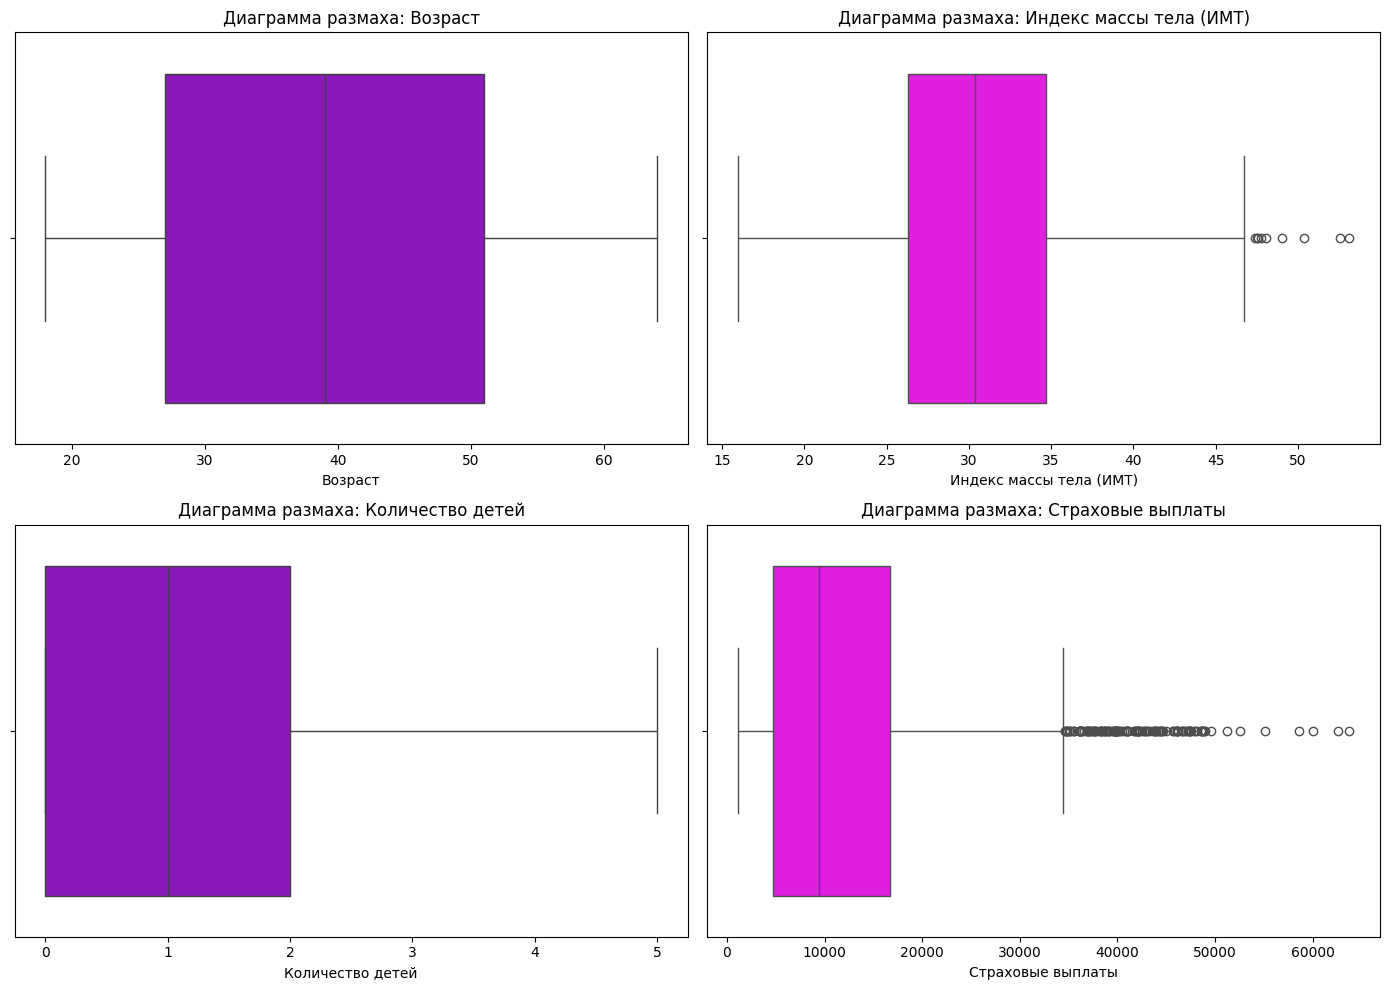


=== Курящие, Страховые выплаты ===
Границы: [-9463.20, 71308.65]
Количество выбросов: 0
Доля выбросов: 0.00%

=== Некурящие, Страховые выплаты ===
Границы: [-7072.32, 22424.22]
Количество выбросов: 46
Доля выбросов: 4.33%


In [9]:
#Выбросы 1.2.7

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

df = pd.read_csv("Medical_insurance_clean.csv")

def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return outliers, lower_bound, upper_bound

numeric_cols = ["age", "bmi", "children", "charges"]
ru_names = {
    "age": "Возраст",
    "bmi": "Индекс массы тела (ИМТ)",
    "children": "Количество детей",
    "charges": "Страховые выплаты",
}

for col in numeric_cols:
    outliers, lb, ub = detect_outliers_iqr(df, col)
    print(f"\n=== {ru_names[col]} ===")
    print(f"Границы: [{lb:.2f}, {ub:.2f}]")
    print(f"Количество выбросов: {len(outliers)}")
    if len(outliers) > 0:
        print(outliers[[col]].head())

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()
colors = ["darkviolet", "fuchsia", "darkviolet", "fuchsia"]

for i, col in enumerate(numeric_cols):
    sns.boxplot(x=df[col], ax=axes[i], color=colors[i])
    axes[i].set_title(f"Диаграмма размаха: {ru_names[col]}")
    axes[i].set_xlabel(ru_names[col])

plt.tight_layout()
plt.savefig("outliers_boxplot.png", dpi=300)
plt.show()

smoker_yes = df[df["smoker"] == "yes"]
smoker_no = df[df["smoker"] == "no"]

for group_name, group_data in [("Курящие", smoker_yes), ("Некурящие", smoker_no)]:
    outliers, lb, ub = detect_outliers_iqr(group_data, "charges")
    print(f"\n=== {group_name}, Страховые выплаты ===")
    print(f"Границы: [{lb:.2f}, {ub:.2f}]")
    print(f"Количество выбросов: {len(outliers)}")
    print(f"Доля выбросов: {len(outliers)/len(group_data)*100:.2f}%")

In [ ]:
#Условная фильтрация сэмплов 1.2.8

import pandas as pd

df = pd.read_csv('Medical_insurance_clean.csv')

smokers = df[df['smoker'] == 'yes']
print(f"Количество курящих клиентов: {len(smokers)}")

older_obese = df[(df['age'] > 50) & (df['bmi'] > 30)]
print(f"\nКоличество клиентов старше 50 лет с bmi > 30: {len(older_obese)}")

southeast_family_smokers = df[(df['region'] == 'southeast') &
                               (df['children'] >= 1) &
                               (df['smoker'] == 'yes')]
print(f"\nКоличество клиентов (southeast, дети >=1, курящие): {len(southeast_family_smokers)}")


Количество курящих клиентов: 274

Количество клиентов старше 50 лет с bmi > 30: 219

Количество клиентов (southeast, дети >=1, курящие): 51


In [11]:
#Добавление шума 1.2.9

import numpy as np
import pandas as pd

df = pd.read_csv("Medical_insurance_clean.csv")
df_noisy = df.copy()

np.random.seed(37)
df_noisy["age"] = df_noisy["age"] + np.random.normal(0, 2.0, len(df_noisy))
df_noisy["bmi"] = df_noisy["bmi"] + np.random.normal(0, 1.5, len(df_noisy))

df_noisy["age"] = df_noisy["age"].clip(0, 100)
df_noisy["bmi"] = df_noisy["bmi"].clip(10, 60)

df_noisy.to_csv("Medical_insurance_noisy.csv", index=False)

print(
    pd.DataFrame(
        {"Исходный": df["age"].head(10), "Зашумленный": df_noisy["age"].head(10)}
    )
)
print(
    pd.DataFrame(
        {"Исходный": df["bmi"].head(10), "Зашумленный": df_noisy["bmi"].head(10)}
    )
)


   Исходный  Зашумленный
0        19    18.891073
1        18    19.348616
2        28    28.693294
3        33    30.399308
4        32    35.037024
5        31    32.979647
6        46    46.555362
7        37    36.102821
8        37    38.923932
9        60    58.344843
   Исходный  Зашумленный
0    27.900    28.708249
1    33.770    33.318599
2    33.000    32.895370
3    22.705    23.414210
4    28.880    28.789876
5    25.740    25.058329
6    33.440    33.657154
7    27.740    27.301652
8    29.830    29.736713
9    25.840    25.609007


In [12]:
#Преобразование числовых данных в категориальные 1.2.10

import pandas as pd

df = pd.read_csv("Medical_insurance_noisy.csv")

bins_age = [0, 18, 30, 45, 60, 100]
labels_age = ["0-18", "19-30", "31-45", "46-60", "60+"]
df["age_group"] = pd.cut(
    df["age"], bins=bins_age, labels=labels_age, right=False
)

bins_bmi = [0, 18.5, 25, 30, 100]
labels_bmi = ["Underweight", "Normal", "Overweight", "Obese"]
df["bmi_category"] = pd.cut(
    df["bmi"], bins=bins_bmi, labels=labels_bmi, right=False
)

df["children_group"] = df["children"].apply(
    lambda x: "3+" if x >= 3 else str(x)
)

q25, q50, q75 = df["charges"].quantile([0.25, 0.5, 0.75])
bins_charges = [0, q25, q50, q75, df["charges"].max() + 1]
labels_charges = ["Low", "Medium", "High", "Very High"]
df["charges_category"] = pd.cut(
    df["charges"], bins=bins_charges, labels=labels_charges, right=False
)

df_final = df[
    [
        "sex",
        "smoker",
        "region",
        "age_group",
        "bmi_category",
        "children_group",
        "charges_category",
    ]
]
df_final.to_csv("Medical_insurance_categorical.csv", index=False)

print(df_final.head(10))

      sex smoker     region age_group bmi_category children_group  \
0  female    yes  southwest     19-30   Overweight              0   
1    male     no  southeast     19-30        Obese              1   
2    male     no  southeast     19-30        Obese             3+   
3    male     no  northwest     31-45       Normal              0   
4    male     no  northwest     31-45   Overweight              0   
5  female     no  southeast     31-45   Overweight              0   
6  female     no  southeast     46-60        Obese              1   
7  female     no  northwest     31-45   Overweight             3+   
8    male     no  northeast     31-45   Overweight              2   
9  female     no  northwest     46-60   Overweight              0   

  charges_category  
0        Very High  
1              Low  
2              Low  
3        Very High  
4              Low  
5              Low  
6           Medium  
7           Medium  
8           Medium  
9        Very High  


Размер исходного датасета: (2772, 7)
Размер категориального датасета: (1337, 7)


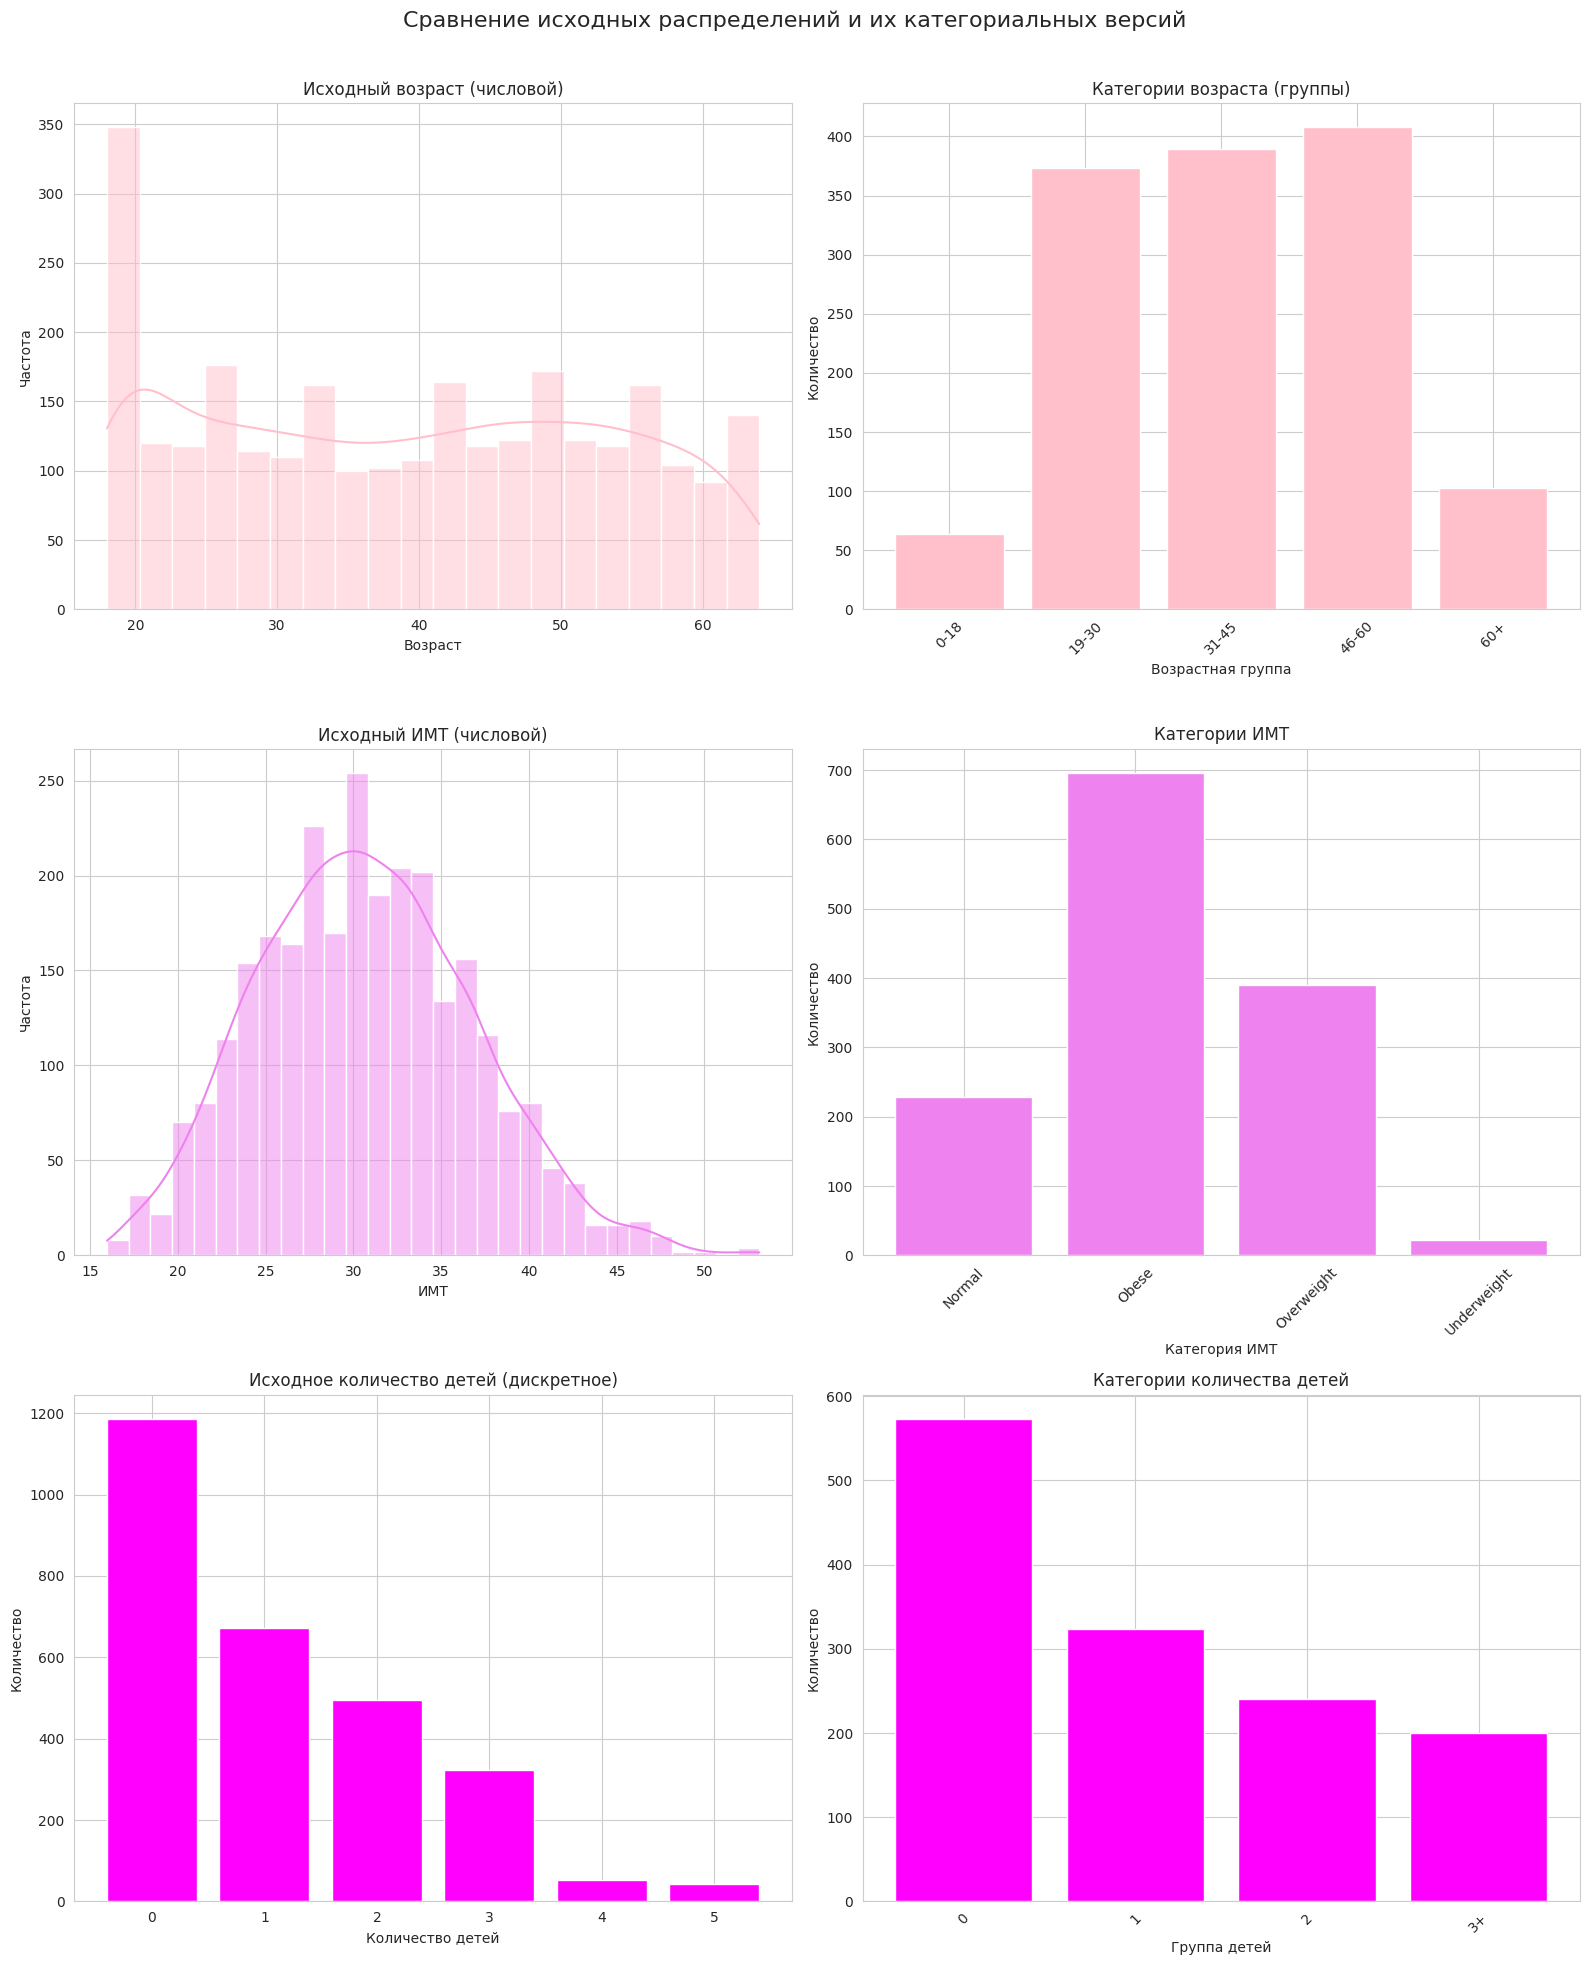


=== Числовые характеристики исходных признаков ===
               age          bmi     children
count  2772.000000  2772.000000  2772.000000
mean     39.109668    30.701349     1.101732
std      14.081459     6.129449     1.214806
min      18.000000    15.960000     0.000000
25%      26.000000    26.220000     0.000000
50%      39.000000    30.447500     1.000000
75%      51.000000    34.770000     2.000000
max      64.000000    53.130000     5.000000

=== Распределение категориальных признаков (в процентах) ===

Признак: Возрастные группы
age_group
0-18      4.786836
19-30    27.898280
31-45    29.094989
46-60    30.516081
60+       7.703815
Name: proportion, dtype: float64

Признак: Категории ИМТ
bmi_category
Normal         17.127898
Obese          52.056844
Overweight     29.169783
Underweight     1.645475
Name: proportion, dtype: float64

Признак: Группы по количеству детей
children_group
0     42.857143
1     24.233358
2     17.950636
3+    14.958863
Name: proportion, dtype: floa

In [17]:
#Оценка изменения в данных после фильтрации 1.2.12.

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

df_original = pd.read_csv("Medical_insurance.csv")
df_cat = pd.read_csv("Medical_insurance_categorical.csv")

print("Размер исходного датасета:", df_original.shape)
print("Размер категориального датасета:", df_cat.shape)

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)

fig, axes = plt.subplots(3, 2, figsize=(16, 20))
fig.suptitle(
    "Сравнение исходных распределений и их категориальных версий",
    fontsize=16,
    y=0.98,
)

ax1 = axes[0, 0]
sns.histplot(df_original["age"], bins=20, kde=True, ax=ax1, color="pink")
ax1.set_title("Исходный возраст (числовой)")
ax1.set_xlabel("Возраст")
ax1.set_ylabel("Частота")

ax2 = axes[0, 1]
age_counts = df_cat["age_group"].value_counts().sort_index()
ax2.bar(age_counts.index, age_counts.values, color="pink")
ax2.set_title("Категории возраста (группы)")
ax2.set_xlabel("Возрастная группа")
ax2.tick_params(axis="x", rotation=45)
ax2.set_ylabel("Количество")

ax1 = axes[1, 0]
sns.histplot(df_original["bmi"], bins=30, kde=True, ax=ax1, color="violet")
ax1.set_title("Исходный ИМТ (числовой)")
ax1.set_xlabel("ИМТ")
ax1.set_ylabel("Частота")

ax2 = axes[1, 1]
bmi_counts = df_cat["bmi_category"].value_counts().sort_index()
ax2.bar(bmi_counts.index, bmi_counts.values, color="violet")
ax2.set_title("Категории ИМТ")
ax2.set_xlabel("Категория ИМТ")
ax2.tick_params(axis="x", rotation=45)
ax2.set_ylabel("Количество")

ax1 = axes[2, 0]
children_counts = df_original["children"].value_counts().sort_index()
ax1.bar(children_counts.index, children_counts.values, color="fuchsia")
ax1.set_title("Исходное количество детей (дискретное)")
ax1.set_xlabel("Количество детей")
ax1.set_xticks(range(0, 6))
ax1.set_ylabel("Количество")

ax2 = axes[2, 1]
child_counts = df_cat["children_group"].value_counts().sort_index()
ax2.bar(child_counts.index, child_counts.values, color="fuchsia")
ax2.set_title("Категории количества детей")
ax2.set_xlabel("Группа детей")
ax2.tick_params(axis="x", rotation=45)
ax2.set_ylabel("Количество")

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig("categorical_comparison.png", dpi=300)
plt.show()

print("\n=== Числовые характеристики исходных признаков ===")
print(df_original[["age", "bmi", "children"]].describe())

print("\n=== Распределение категориальных признаков (в процентах) ===")
ru_labels = {
    "age_group": "Возрастные группы",
    "bmi_category": "Категории ИМТ",
    "children_group": "Группы по количеству детей"
}

for col in ["age_group", "bmi_category", "children_group"]:
    print(f"\nПризнак: {ru_labels[col]}")
    print(df_cat[col].value_counts(normalize=True).sort_index() * 100)

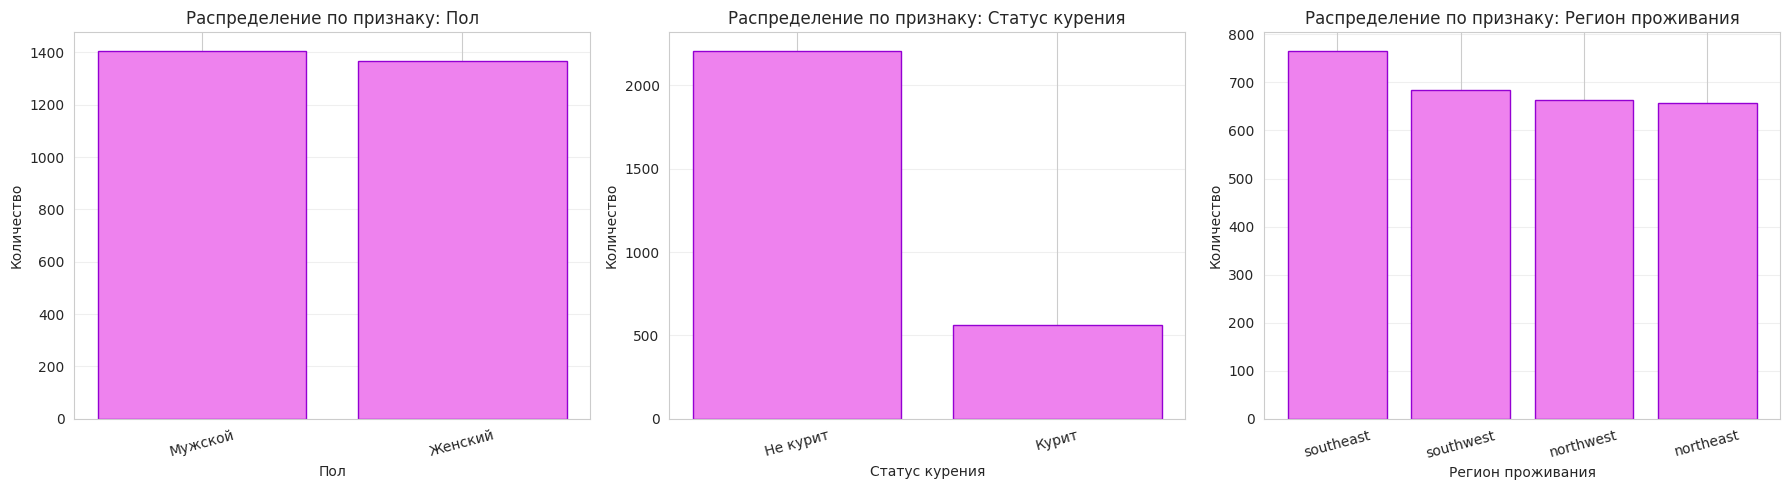

In [18]:
#Диаграммы распределения категориальных данных 1.3.2

import matplotlib.pyplot as plt
import pandas as pd

df = pd.read_csv("Medical_insurance.csv")

translate_values = {
    "sex": {"male": "Мужской", "female": "Женский"},
    "smoker": {"yes": "Курит", "no": "Не курит"},
}

categorical_cols = ["sex", "smoker", "region"]
ru_names = {
    "sex": "Пол",
    "smoker": "Статус курения",
    "region": "Регион проживания",
}

plt.figure(figsize=(18, 5))

for i, col in enumerate(categorical_cols, start=1):
    plt.subplot(1, 3, i)

    if col in translate_values:
        temp_series = df[col].map(translate_values[col])
    else:
        temp_series = df[col]

    counts = temp_series.value_counts()

    plt.bar(counts.index, counts.values, color="violet", edgecolor="darkviolet")
    plt.title(f"Распределение по признаку: {ru_names[col]}")
    plt.xlabel(ru_names[col])
    plt.ylabel("Количество")
    plt.grid(axis="y", alpha=0.3)
    plt.tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.savefig("categorical_distribution.png", dpi=300)
plt.show()

In [19]:
#Преобразование категориальных данных в числовые 1.3.3.

import pandas as pd
from sklearn.preprocessing import LabelEncoder

df = pd.read_csv("Medical_insurance.csv")

df["sex"] = df["sex"].map({"male": 1, "female": 0})

le = LabelEncoder()
df["smoker"] = le.fit_transform(df["smoker"])
df["region"] = le.fit_transform(df["region"])

df.to_csv("medical_insurance_encoded.csv", index=False)

print("Первые 5 строк закодированных данных:")
print(df.head())

Первые 5 строк закодированных данных:
   age  sex     bmi  children  smoker  region      charges
0   19    0  27.900         0       1       3  16884.92400
1   18    1  33.770         1       0       2   1725.55230
2   28    1  33.000         3       0       2   4449.46200
3   33    1  22.705         0       0       1  21984.47061
4   32    1  28.880         0       0       1   3866.85520


In [20]:
#Введение новой категории 1.3.5.

import pandas as pd

df = pd.read_csv("medical_insurance_encoded.csv")

df["age_group"] = pd.cut(
    df["age"],
    bins=[0, 30, 50, 100],
    labels=["молодой", "средний", "пожилой"],
    right=False,
)

df["bmi_category"] = pd.cut(
    df["bmi"],
    bins=[0, 25, 30, 100],
    labels=["норма", "избыточный вес", "ожирение"],
    right=False,
)


def assign_risk(row):
    if row["smoker"] == 1:
        return "high"
    else:
        if row["age_group"] == "пожилой" or row["bmi_category"] == "ожирение":
            return "medium"
        elif (
            row["age_group"] == "средний"
            and row["bmi_category"] == "избыточный вес"
        ):
            return "medium"
        else:
            return "low"


df["risk_category"] = df.apply(assign_risk, axis=1)
df.drop(["age_group", "bmi_category"], axis=1, inplace=True)
df.to_csv("medical_insurance_with_risk.csv", index=False)

print("Первые 5 строк данных с категориями риска:")
print(df.head())

Первые 5 строк данных с категориями риска:
   age  sex     bmi  children  smoker  region      charges risk_category
0   19    0  27.900         0       1       3  16884.92400          high
1   18    1  33.770         1       0       2   1725.55230        medium
2   28    1  33.000         3       0       2   4449.46200        medium
3   33    1  22.705         0       0       1  21984.47061           low
4   32    1  28.880         0       0       1   3866.85520        medium
